<a href="https://colab.research.google.com/github/Psalmist70/fraud-detection-system/blob/main/notebooks/fraud_model_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Replace <your-folder> with the folder path in Drive
file_path = '/content/drive/MyDrive/FraudDetection/creditcard.csv'

# Load dataset
df = pd.read_csv(file_path)

# Quick look at the first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# Count of each class
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
# Step 0: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing and model preparation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [ ]:
# Adjust file path according to your Drive
file_path = '/content/drive/MyDrive/FraudDetection/creditcard.csv'
df = pd.read_csv(file_path)

# Quick look
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


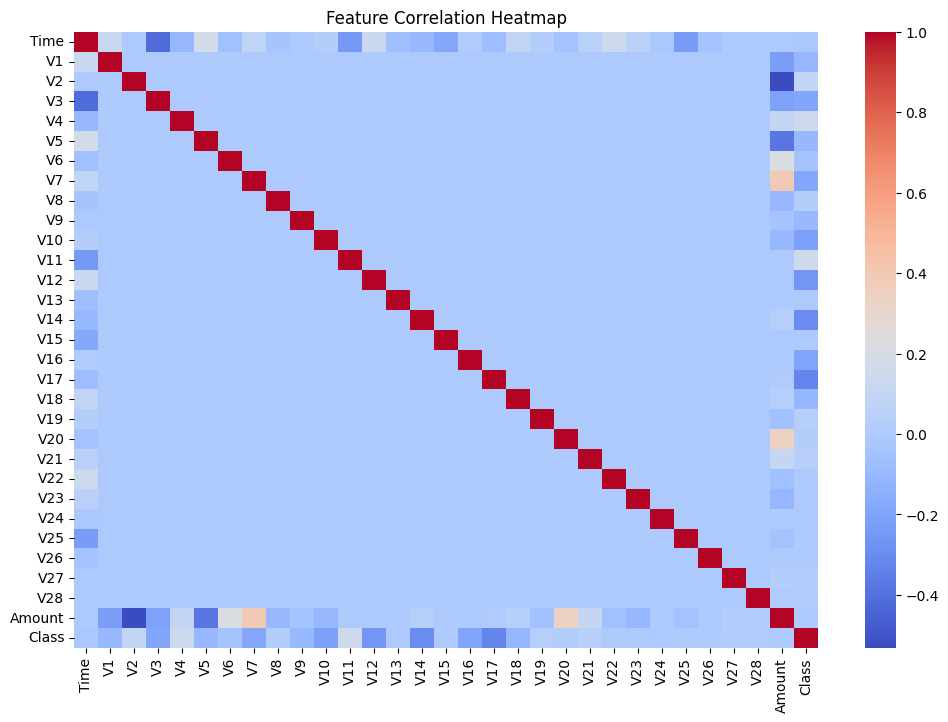

In [ ]:
# Summary statistics for numerical features
df.describe()

# Correlation heatmap (optional, helps understand feature relationships)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

Class
0    284315
1       492
Name: count, dtype: int64


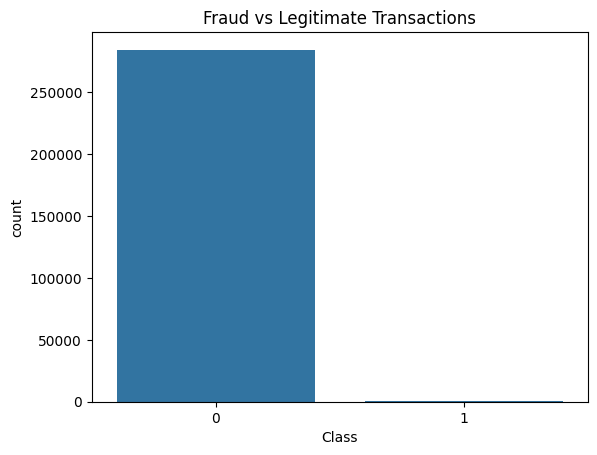

In [ ]:
print(df['Class'].value_counts())
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # all 30 features scaled

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Original training set class distribution:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())

Original training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
print("Training features shape:", X_train_res.shape)
print("Test features shape:", X_test.shape)

Training features shape: (454902, 30)
Test features shape: (56962, 30)


In [ ]:
# Step 0: Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
# Features to use
selected_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
                     'V11','V12','V13','V14','V15','V16','V17','V18','V19',
                     'V20','V21','V22','V23','V24','V25','V26','V27','V28',
                     'Amount', 'Time']

X_selected = X_train_res[selected_features]
X_test_selected = X_test[selected_features]

print("Selected features shape:", X_selected.shape)

Selected features shape: (454902, 30)


In [ ]:
print("Training feature set ready shape:", X_selected.shape)
print("Test feature set ready shape:", X_test_selected.shape)

Training feature set ready shape: (454902, 30)
Test feature set ready shape: (56962, 30)


In [ ]:
# Step 0: Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Initialize Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train model
log_reg.fit(X_selected, y_train_res)

# Predict on test set
y_pred_lr = log_reg.predict(X_test_selected)

# Evaluate
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")

Logistic Regression Performance:
Accuracy: 0.9878
Precision: 0.1137
Recall: 0.8980
F1-score: 0.2018


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    max_depth=None,          # expand until all leaves are pure
    class_weight='balanced', # handle imbalance
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_selected, y_train_res)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_selected)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

Random Forest Performance:
Accuracy: 0.9995
Precision: 0.8384
Recall: 0.8469
F1-score: 0.8426


In [ ]:
# Example: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_selected, y_train_res)
y_pred_dt = dt_model.predict(X_test_selected)
print("Decision Tree F1-score:", f1_score(y_test, y_pred_dt))

Decision Tree F1-score: 0.5551601423487544


In [ ]:
# !pip install xgboost
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=len(y_train_res[y_train_res==0])/len(y_train_res[y_train_res==1]),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_selected, y_train_res)
y_pred_xgb = xgb_model.predict(X_test_selected)
print("XGBoost F1-score:", f1_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:24:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost F1-score: 0.8177339901477833


In [ ]:
# Import metrics and visualization tools
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
# Predict on test set
y_pred = rf_model.predict(X_test_selected)

# Compute key metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Model Evaluation on Test Set")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Random Forest Model Evaluation on Test Set
Accuracy: 0.9995
Precision: 0.8384
Recall: 0.8469
F1-score: 0.8426


<Figure size 600x600 with 0 Axes>

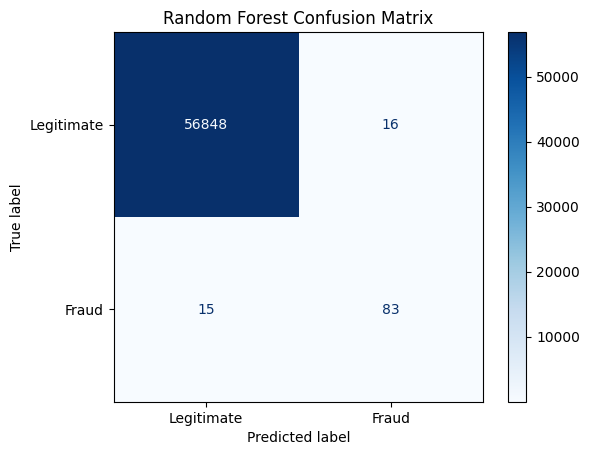

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])

# Plot
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf_model,
    'Decision Tree': dt_model,
    'XGBoost': xgb_model
}

for name, model in models.items():
    y_pred_model = model.predict(X_test_selected)
    print(f"{name}: F1-score = {f1_score(y_test, y_pred_model):.4f}, Recall = {recall_score(y_test, y_pred_model):.4f}")

Logistic Regression: F1-score = 0.2018, Recall = 0.8980
Random Forest: F1-score = 0.8426, Recall = 0.8469
Decision Tree: F1-score = 0.5552, Recall = 0.7959
XGBoost: F1-score = 0.8177, Recall = 0.8469


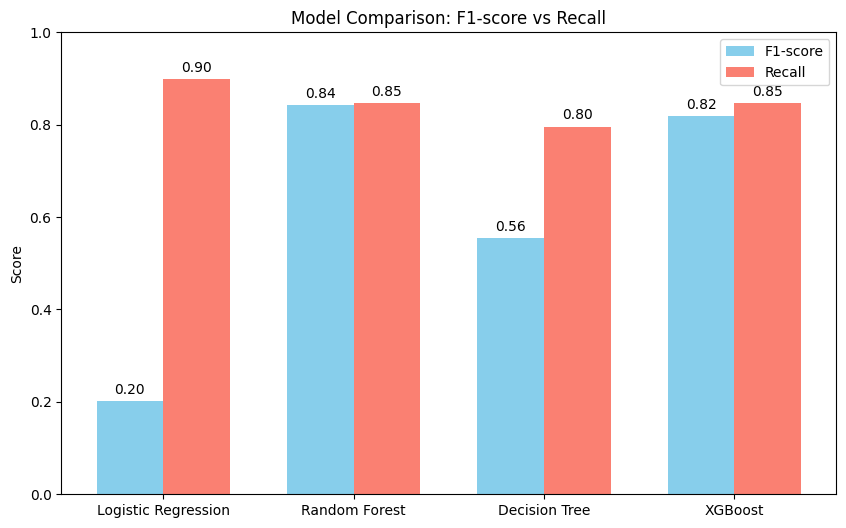

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# List of models
model_names = ['Logistic Regression', 'Random Forest', 'Decision Tree', 'XGBoost']

# Calculate metrics for each model
f1_scores = [
    f1_score(y_test, log_reg.predict(X_test_selected)),
    f1_score(y_test, rf_model.predict(X_test_selected)),
    f1_score(y_test, dt_model.predict(X_test_selected)),
    f1_score(y_test, xgb_model.predict(X_test_selected))
]

recall_scores = [
    recall_score(y_test, log_reg.predict(X_test_selected)),
    recall_score(y_test, rf_model.predict(X_test_selected)),
    recall_score(y_test, dt_model.predict(X_test_selected)),
    recall_score(y_test, xgb_model.predict(X_test_selected))
]

# Plot
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, f1_scores, width, label='F1-score', color='skyblue')
rects2 = ax.bar(x + width/2, recall_scores, width, label='Recall', color='salmon')

# Add labels
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Model Comparison: F1-score vs Recall')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

# Annotate values on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3), textcoords='offset points',
                    ha='center', va='bottom')

plt.show()

In [ ]:
import joblib

In [ ]:
from sklearn.ensemble import VotingClassifier

# Define Voting Ensemble with soft voting
ensemble_model = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    voting='soft'
)

# Train ensemble on the preprocessed training data
ensemble_model.fit(X_selected, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:05:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            fea...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
import os

# Create 'model' folder
os.makedirs('model', exist_ok=True)

In [ ]:
import joblib

# Save the trained ensemble model
joblib.dump(ensemble_model, 'model/fraud_ensemble_model.pkl')

# Save the scaler
joblib.dump(scaler, 'model/scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
from google.colab import files

files.download('model/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
joblib.dump(ensemble_model, 'model/fraud_ensemble_model.pkl', compress=3)

['model/fraud_ensemble_model.pkl']

In [ ]:
from google.colab import files

# Download the compressed ensemble model
files.download('model/fraud_ensemble_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install flask pandas numpy scikit-learn joblib

In [ ]:
!pip freeze > requirements.txt

In [ ]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install flask pyngrok requests

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/FraudDetection/creditcard.csv')

In [ ]:
!git clone https://github.com/Psalmist70/fraud-detection-system.git

Cloning into 'fraud-detection-system'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 74 (delta 28), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 17.17 MiB | 15.36 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [ ]:
%cd fraud-detection-system/api

/content/fraud-detection-system/api/fraud-detection-system/api


In [ ]:
!python /content/fraud-detection-system/api/app.py &

 * Serving Flask app 'app'
 * Debug mode: on
Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(5000)
print(public_url)

NgrokTunnel: "https://choleraic-isabell-blowy.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
import requests

url = "https://choleraic-isabell-blowy.ngrok-free.dev//predict-random"

response = requests.post(url)
print(response.json())

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
from pyngrok import ngrok
import threading

# Start Flask in background
def run_app():
    !python app.py

thread = threading.Thread(target=run_app)
thread.start()

# Open tunnel
public_url = ngrok.connect(5000)
print("Public URL:", public_url)

  File "/content/fraud-detection-system/api/fraud-detection-system/api/app.py", line 43
    features_scaled = scaler.transform(features)  # now works for 30 features
                                                                             ^
IndentationError: unindent does not match any outer indentation level
Public URL: NgrokTunnel: "https://choleraic-isabell-blowy.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
!ngrok config add-authtoken 3BUbz1zzYnqxNbsx5Qwym9CnCn2_3AxELVVrUk2uKvwY6QcrD

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
import requests

url = "https://choleraic-isabell-blowy.ngrok-free.dev/predict-custom"   # replace with your ngrok URL

data = {
    "amount": 5000,
    "time": "afternoon"
}

response = requests.post(url, json=data)
print(response.json())

{'amount': 5000.0, 'prediction': 'Legitimate', 'probability': 0.005000004877554805, 'time': 'afternoon'}


In [ ]:
import requests

url = "https://choleraic-isabell-blowy.ngrok-free.dev/predict-selected"

data = {
    "TXN_001": 10
}

response = requests.post(url, json=data)
print(response.json())

{'error': 'Invalid transaction ID'}


In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/FraudDetection/creditcard.csv.zip')

In [5]:
!git clone https://github.com/Psalmist70/fraud-detection-system.git

Cloning into 'fraud-detection-system'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 107 (delta 46), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 17.17 MiB | 14.24 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [6]:
%cd fraud-detection-system/api

/content/fraud-detection-system/api


In [8]:
!cp /content/drive/MyDrive/FraudDetection/creditcard.csv.zip ./

In [10]:
!git config --global user.email "balogunoluwasegun6@gmail.com"
!git config --global user.name "Psalmist70"

!git add creditcard.csv.zip
!git commit -m "Add creditcard.csv.zip for Render deployment"
!git push origin main

[main c0393c4] Add creditcard.csv.zip for Render deployment
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 api/creditcard.csv.zip
fatal: could not read Username for 'https://github.com': No such device or address
